<a href="https://colab.research.google.com/github/mokhivibes/ml_course_courseworks/blob/main/7_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df = pd.read_csv("/content/df_clean_HOUSE_PRICE.csv")
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1394,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1395,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1396,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1397,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1399 non-null   int64  
 1   MSZoning       1399 non-null   object 
 2   LotFrontage    1399 non-null   float64
 3   LotArea        1399 non-null   int64  
 4   Street         1399 non-null   object 
 5   LotShape       1399 non-null   object 
 6   LandContour    1399 non-null   object 
 7   Utilities      1399 non-null   object 
 8   LotConfig      1399 non-null   object 
 9   LandSlope      1399 non-null   object 
 10  Neighborhood   1399 non-null   object 
 11  Condition1     1399 non-null   object 
 12  Condition2     1399 non-null   object 
 13  BldgType       1399 non-null   object 
 14  HouseStyle     1399 non-null   object 
 15  OverallQual    1399 non-null   int64  
 16  OverallCond    1399 non-null   int64  
 17  YearBuilt      1399 non-null   int64  
 18  YearRemo

In [ ]:
df.shape

(1399, 74)

In [ ]:
df.isnull().sum().sort_values(ascending=False)
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,...,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000
mean,57.487491,69.047891,10155.280915,5.983560,5.591137,1970.080772,1984.058613,89.725518,417.333095,47.478914,...,89.621158,44.892066,22.378127,3.231594,14.634024,2.482487,45.385275,6.312366,2007.819871,170237.127234
std,42.803603,21.522816,8324.834198,1.282272,1.118236,30.009463,20.661160,159.219858,428.401771,162.648530,...,121.798431,65.718951,61.454480,28.563071,54.752105,38.289681,506.746349,2.703584,1.327762,59230.130817
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,60.000000,7442.000000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129000.000000
50%,50.000000,69.000000,9317.000000,6.000000,5.000000,1971.000000,1992.000000,0.000000,370.000000,0.000000,...,0.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,159500.000000
75%,70.000000,78.000000,11316.500000,7.000000,6.000000,1999.000000,2003.000000,143.000000,686.000000,0.000000,...,165.000000,64.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,203500.000000
max,190.000000,313.000000,164660.000000,10.000000,9.000000,2009.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,736.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,340000.000000


In [ ]:
df.dtypes.value_counts()

,count
object,37
int64,34
float64,3


In [ ]:
df.isnull().sum().sum()


np.int64(512)

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('None') #df[cat_cols].mode()[0] => mode bilan toldiradi
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


np.int64(0)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
sns.set_theme()

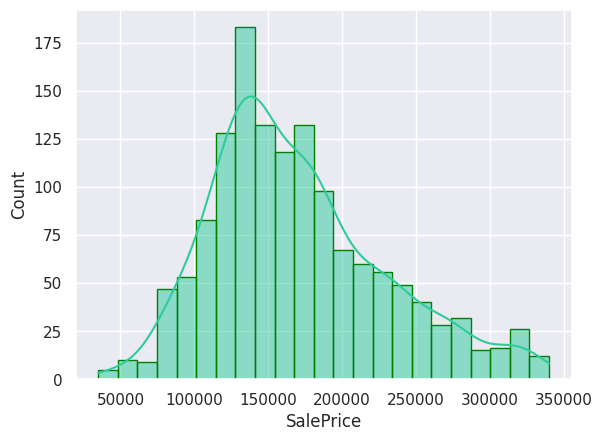

In [ ]:
#1. Histogram
sns.histplot(df['SalePrice'], color='#2ECB9B', kde=True, edgecolor = 'green')
plt.show()

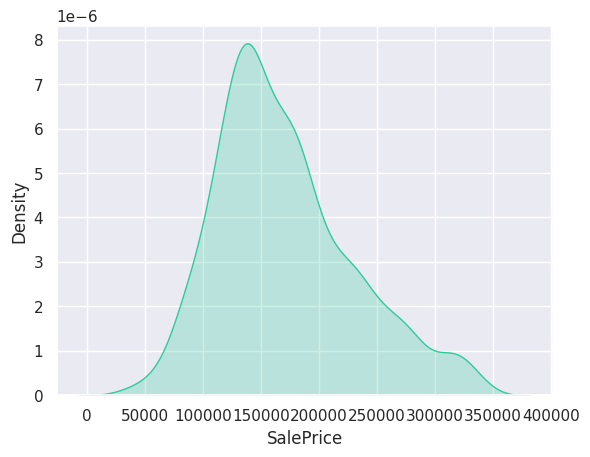

In [ ]:
#2. KDE
sns.kdeplot(df['SalePrice'], fill=True, color='#2ECB9B')
plt.show()

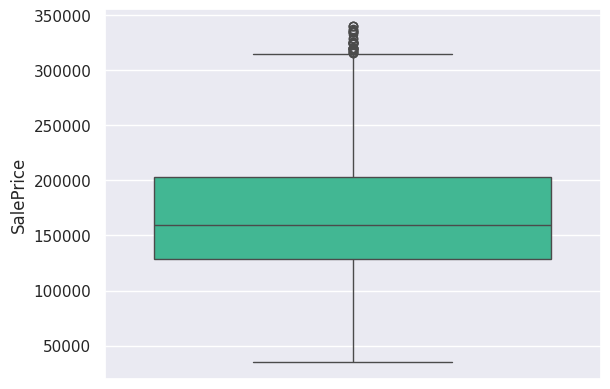

In [ ]:
#3. Box Plot
sns.boxplot(data=df, y='SalePrice', color='#2ECB9B')
plt.show()

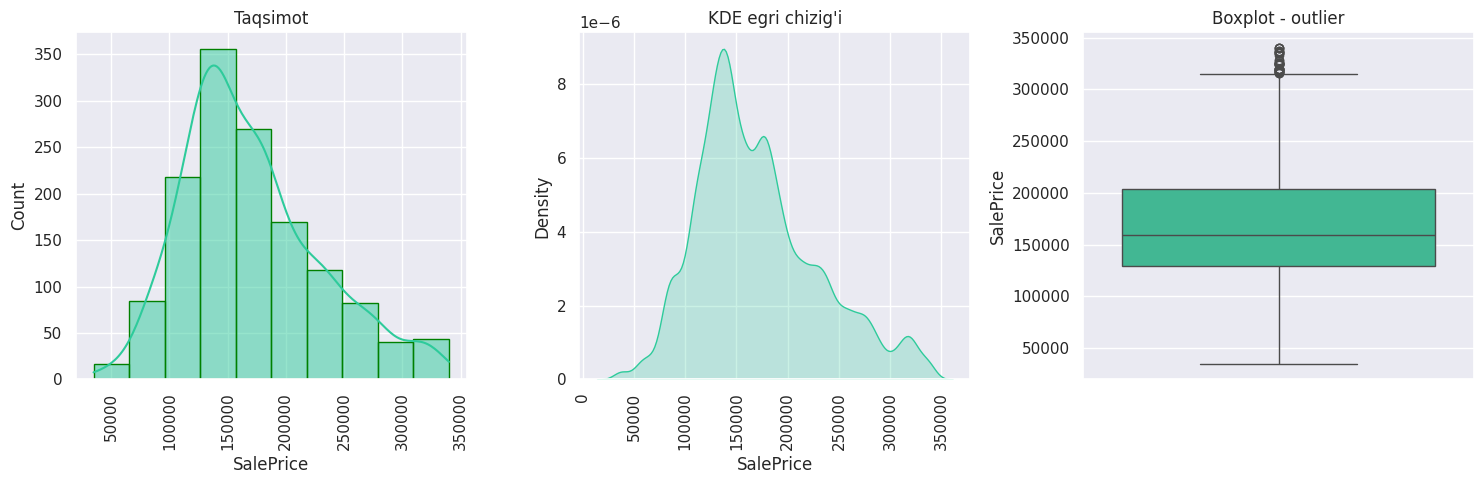

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#1. Histogram
sns.histplot(df['SalePrice'], ax=axes[0], color='#2ECB9B', kde=True, edgecolor = 'green', bins=10)
axes[0].set_title('Taqsimot')
axes[0].tick_params(axis='x', rotation=90)


#2. KDE
sns.kdeplot(df['SalePrice'], ax=axes[1],fill=True, color='#2ECB9B', bw_adjust=0.5)
axes[1].set_title('KDE egri chizig\'i')
axes[1].tick_params(axis='x', rotation=90)

#3. Box Plot
sns.boxplot(data=df, y='SalePrice', ax=axes[2],color='#2ECB9B')
axes[2].set_title('Boxplot - outlier')

plt.tight_layout()
plt.show()

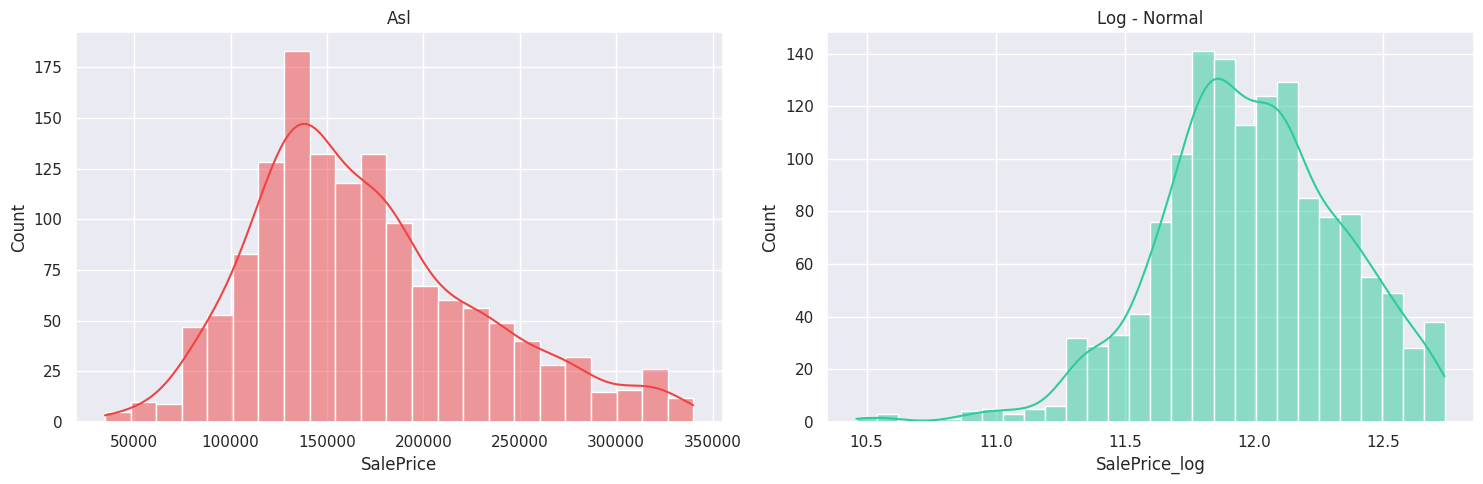

In [ ]:
df['SalePrice_log']= np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['SalePrice'], ax=axes[0], color='#EF4444', kde=True)
axes[0].set_title('Asl')

sns.histplot(df['SalePrice_log'], ax=axes[1], color='#2ECB9B', kde=True)
axes[1].set_title('Log - Normal')

plt.tight_layout()
plt.show()

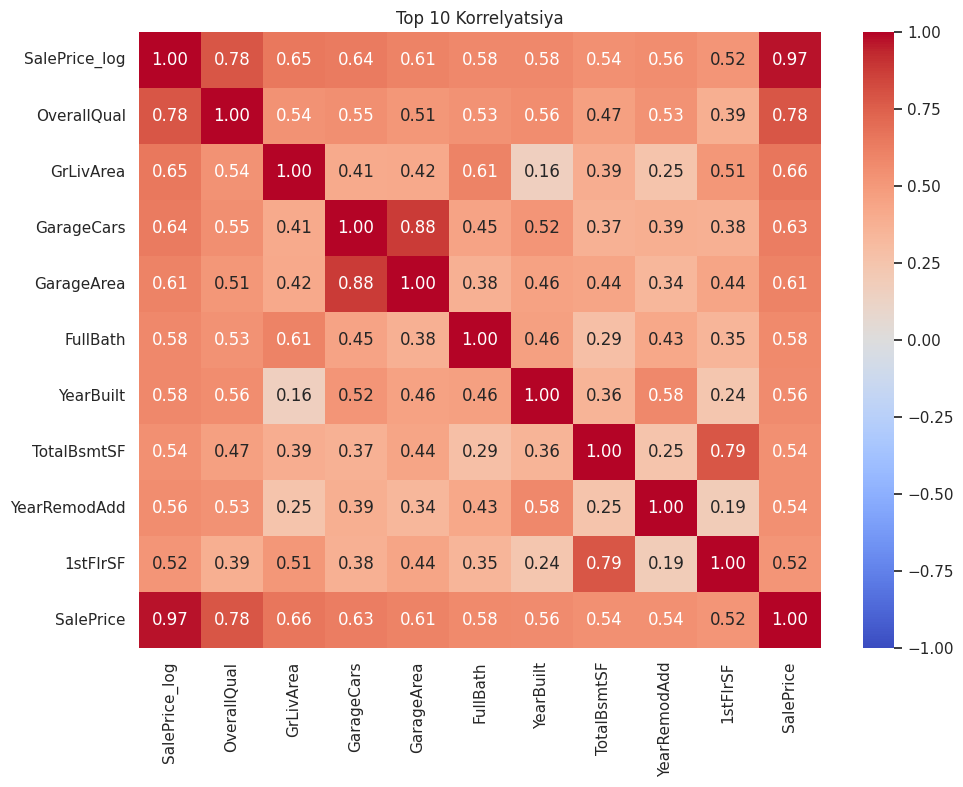

In [ ]:
#Raqamli ustunlar

num_df = df.select_dtypes(include='number')
corr= num_df.corr()

#TOp 10 SalePrice bilan
top10=corr['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10).index
top_cols=list(top10)+['SalePrice']

#HeatMap

plt.figure(figsize=(11,8))

sns.heatmap(
    corr[top_cols].loc[top_cols], annot=True, fmt='.2f' ,
    cmap='coolwarm', center=0, vmax=1, vmin=-1
)
plt.title('Top 10 Korrelyatsiya')
plt.show()

/tmp/ipykernel_9556/4226372060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_9556/4226372060.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 71.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6

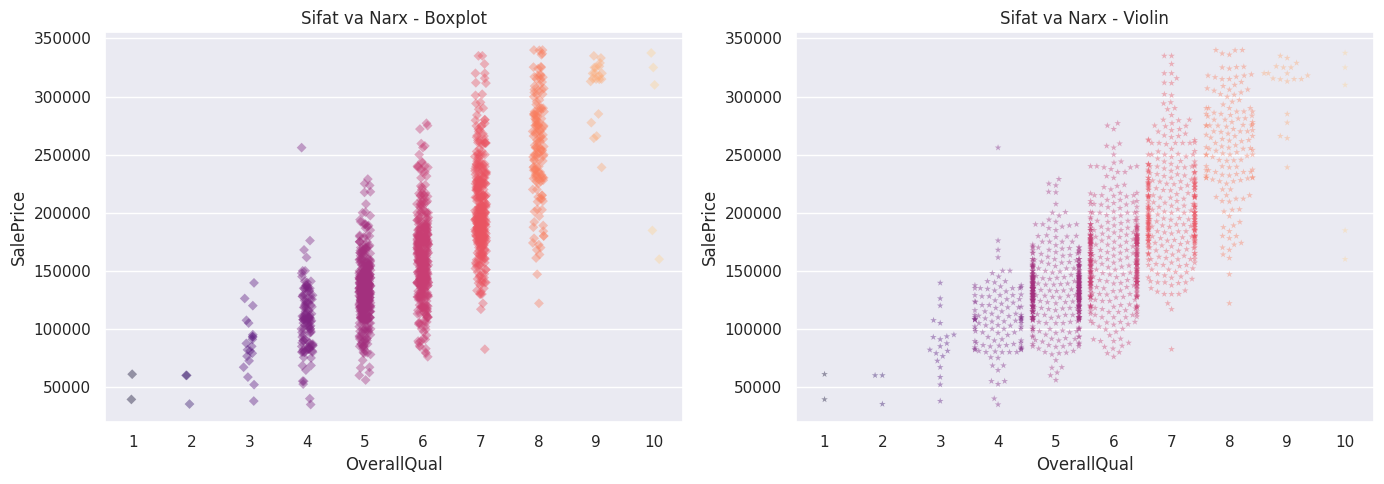

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.stripplot(
    data=df, x='OverallQual', y='SalePrice', alpha=0.4, marker='D',
    palette='magma', ax=axes[0]
)

axes[0].set_title('Sifat va Narx - Boxplot')

sns.swarmplot(
    data=df, x='OverallQual', y='SalePrice', alpha=0.4, marker='*',
    palette='magma', ax=axes[1]
)
axes[1].set_title('Sifat va Narx - Violin')

plt.tight_layout()
plt.show()

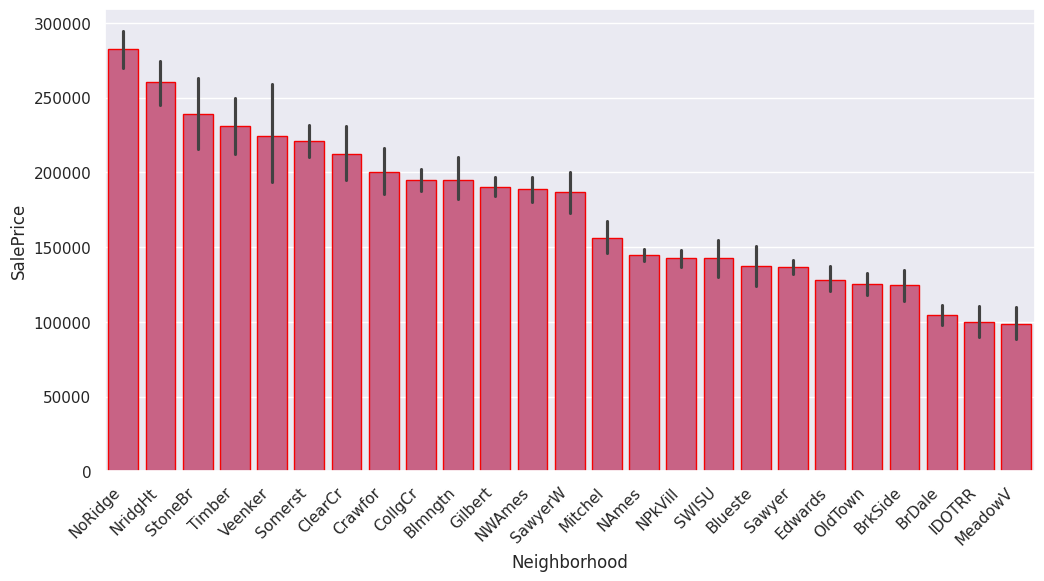

In [ ]:
hood=df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(data=df, x='Neighborhood', y='SalePrice',
            order=hood.index, color='#d9527f', width=0.8, edgecolor="#f50202")
plt.xticks(rotation=45, ha='right')
plt.show()

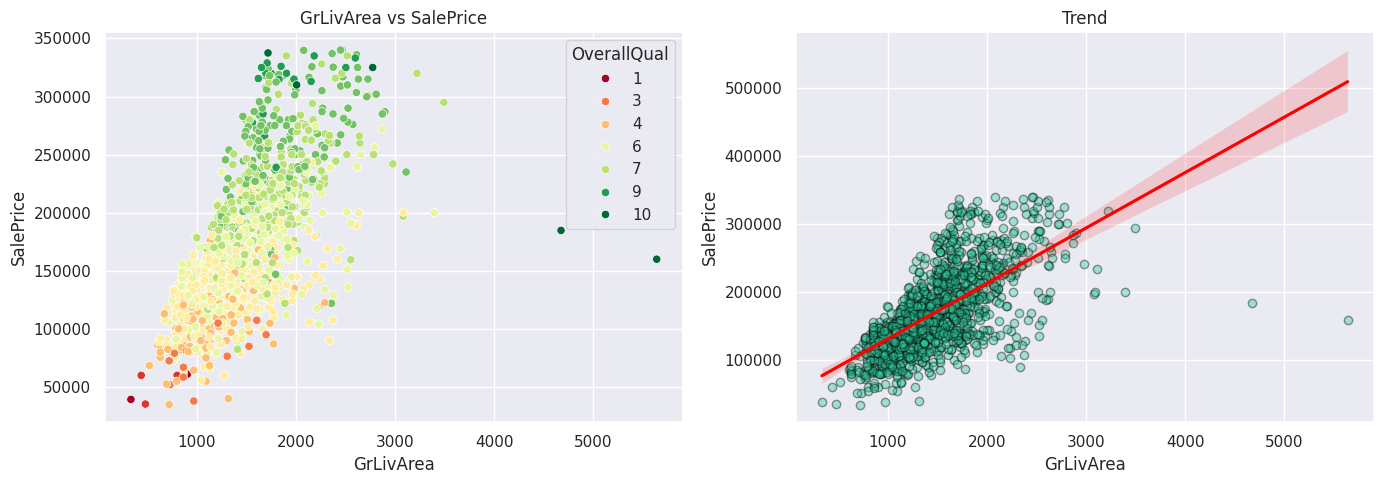

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df, x='GrLivArea', y='SalePrice',
    hue='OverallQual',
    palette='RdYlGn', ax=axes[0]
)

axes[0].set_title('GrLivArea vs SalePrice')

sns.regplot(
    data=df, x='GrLivArea', y='SalePrice',
    scatter_kws = {"alpha":0.4, "marker":'D', 'color': '#2ecb9b', 'edgecolor': 'black'},
    line_kws={'color':'red'}, ax=axes[1]
)
axes[1].set_title('Trend')

plt.tight_layout()
plt.show()